In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATASET_PATH = "data/arxiv-metadata-oai-snapshot.json"
SAMPLE_SIZE  = 5000
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

print(f"Dataset : {DATASET_PATH}")
print(f"Sample  : {SAMPLE_SIZE} papers")
print(f"Seed    : {RANDOM_SEED}")

Dataset : data/arxiv-metadata-oai-snapshot.json
Sample  : 5000 papers
Seed    : 42


### 1.Data Loading

In [10]:
rows = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= SAMPLE_SIZE:
            break
        try:
            p = json.loads(line)
            rows.append({
                'id'         : p.get('id', ''),
                'title'      : p.get('title', '').replace('\n', ' ').strip(),
                'abstract'   : p.get('abstract', '').replace('\n', ' ').strip(),
                'authors'    : p.get('authors', ''),
                'submitter'  : p.get('submitter', ''),
                'categories' : p.get('categories', ''),
                'journal_ref': p.get('journal-ref', '') or '',
                'doi'        : p.get('doi', '') or '',
                'comments'   : p.get('comments', '') or '',
                'report_no'  : p.get('report-no', '') or '',
                'license'    : p.get('license', '') or '',
                'date'       : p.get('update_date', ''),
            })
        except:
            continue

df = pd.DataFrame(rows)

print(f"Dataset loaded")
print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print(f"\nSample entry:")
print(f"   ID         : {df['id'].iloc[0]}")
print(f"   Title      : {df['title'].iloc[0][:60]}...")
print(f"   Abstract   : {df['abstract'].iloc[0][:80]}...")
print(f"   Authors    : {df['authors'].iloc[0][:50]}...")
print(f"   Submitter  : {df['submitter'].iloc[0]}")
print(f"   Categories : {df['categories'].iloc[0]}")
print(f"   Journal    : {df['journal_ref'].iloc[0]}")
print(f"   DOI        : {df['doi'].iloc[0]}")
print(f"   Comments   : {df['comments'].iloc[0]}")
print(f"   Report No  : {df['report_no'].iloc[0]}")
print(f"   License    : {df['license'].iloc[0]}")
print(f"   Date       : {df['date'].iloc[0]}")
df.head(3)


Dataset loaded
Shape      : (5000, 12)
Columns    : ['id', 'title', 'abstract', 'authors', 'submitter', 'categories', 'journal_ref', 'doi', 'comments', 'report_no', 'license', 'date']

Sample entry:
   ID         : 0704.0001
   Title      : Calculation of prompt diphoton production cross sections at ...
   Abstract   : A fully differential calculation in perturbative quantum chromodynamics is prese...
   Authors    : C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Y...
   Submitter  : Pavel Nadolsky
   Categories : hep-ph
   Journal    : Phys.Rev.D76:013009,2007
   DOI        : 10.1103/PhysRevD.76.013009
   Comments   : 37 pages, 15 figures; published version
   Report No  : ANL-HEP-PR-07-12
   License    : 
   Date       : 2008-11-26


,id,title,abstract,authors,submitter,categories,journal_ref,doi,comments,report_no,license,date
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturbati...,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Pavel Nadolsky,hep-ph,"Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,"37 pages, 15 figures; published version",ANL-HEP-PR-07-12,,2008-11-26
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",Ileana Streinu and Louis Theran,Louis Theran,math.CO cs.CG,,,To appear in Graphs and Combinatorics,,http://arxiv.org/licenses/nonexclusive-distrib...,2008-12-13
2,0704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is describe...,Hongjun Pan,Hongjun Pan,physics.gen-ph,,,"23 pages, 3 figures",,,2008-01-13


### 2.Exploration Data

**2.1 : Basic Statistics**

In [11]:
print(f"   Total papers     : {len(df)}")
print(f"   Total columns    : {df.shape[1]}")
print(f"   Missing values   :\n{df.isnull().sum()}")
print(f"\n   Data types :\n{df.dtypes}")

   Total papers     : 5000
   Total columns    : 12
   Missing values   :
id             0
title          0
abstract       0
authors        0
submitter      0
categories     0
journal_ref    0
doi            0
comments       0
report_no      0
license        0
date           0
dtype: int64

   Data types :
id             object
title          object
abstract       object
authors        object
submitter      object
categories     object
journal_ref    object
doi            object
comments       object
report_no      object
license        object
date           object
dtype: object


**2.2 : Category Distribution**



   Unique main categories : 18

   Top 10 categories :
main_category
math        999
astro-ph    972
cond-mat    898
physics     345
hep-ph      326
hep-th      305
quant-ph    257
cs          250
gr-qc       166
math-ph     101
Name: count, dtype: int64


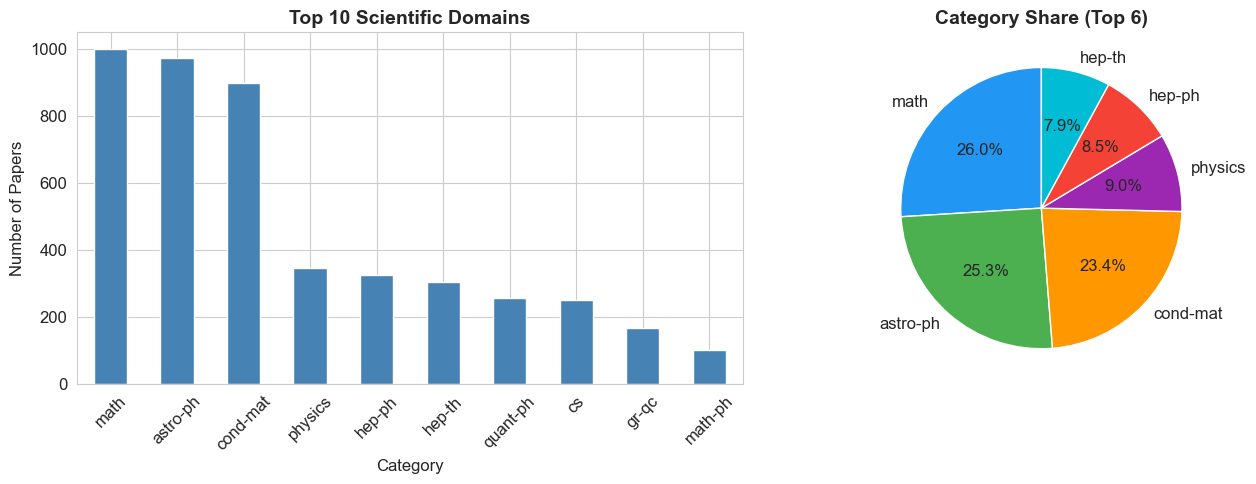

 Plot saved → reports/category_distribution.png


In [12]:
# Extract main category 
df['main_category'] = df['categories'].apply(
    lambda x: x.split()[0].split('.')[0] if x else 'unknown'
)

# Count
cat_counts = df['main_category'].value_counts()
print(f"\n   Unique main categories : {df['main_category'].nunique()}")
print(f"\n   Top 10 categories :\n{cat_counts.head(10)}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cat_counts.head(10).plot(
    kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Top 10 Scientific Domains', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
cat_counts.head(6).plot(
    kind='pie', ax=axes[1],
    autopct='%1.1f%%',
    colors=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4'],
    startangle=90
)
axes[1].set_title('Category Share (Top 6)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('reports/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved → reports/category_distribution.png")

**2.3 : Abstract Length Distribution**



 Average words per abstract  : 122.1
   Min words                   : 2
   Max words                   : 318
   Average chars per abstract  : 802.5


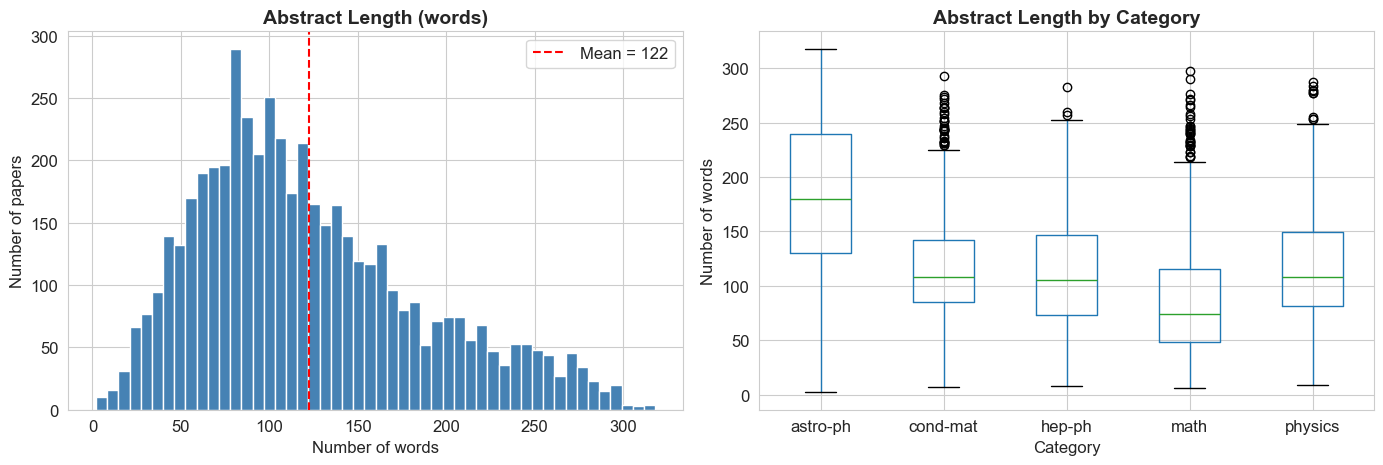

Plot saved → reports/abstract_length.png


In [13]:
# Count words and characters
df['nb_words']    = df['abstract'].apply(lambda x: len(x.split()))
df['nb_chars']    = df['abstract'].apply(lambda x: len(x))

print(f"\n Average words per abstract  : {df['nb_words'].mean():.1f}")
print(f"   Min words                   : {df['nb_words'].min()}")
print(f"   Max words                   : {df['nb_words'].max()}")
print(f"   Average chars per abstract  : {df['nb_chars'].mean():.1f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
axes[0].hist(df['nb_words'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['nb_words'].mean(), color='red', linestyle='--', 
                label=f"Mean = {df['nb_words'].mean():.0f}")
axes[0].set_title('Abstract Length (words)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Number of papers')
axes[0].legend()

# Boxplot by category
top5_cats = df['main_category'].value_counts().head(5).index
df_top5   = df[df['main_category'].isin(top5_cats)]
df_top5.boxplot(column='nb_words', by='main_category', ax=axes[1])
axes[1].set_title('Abstract Length by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of words')
plt.suptitle('')

plt.tight_layout()
plt.savefig('reports/abstract_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/abstract_length.png")

**2.4 : Word Cloud**


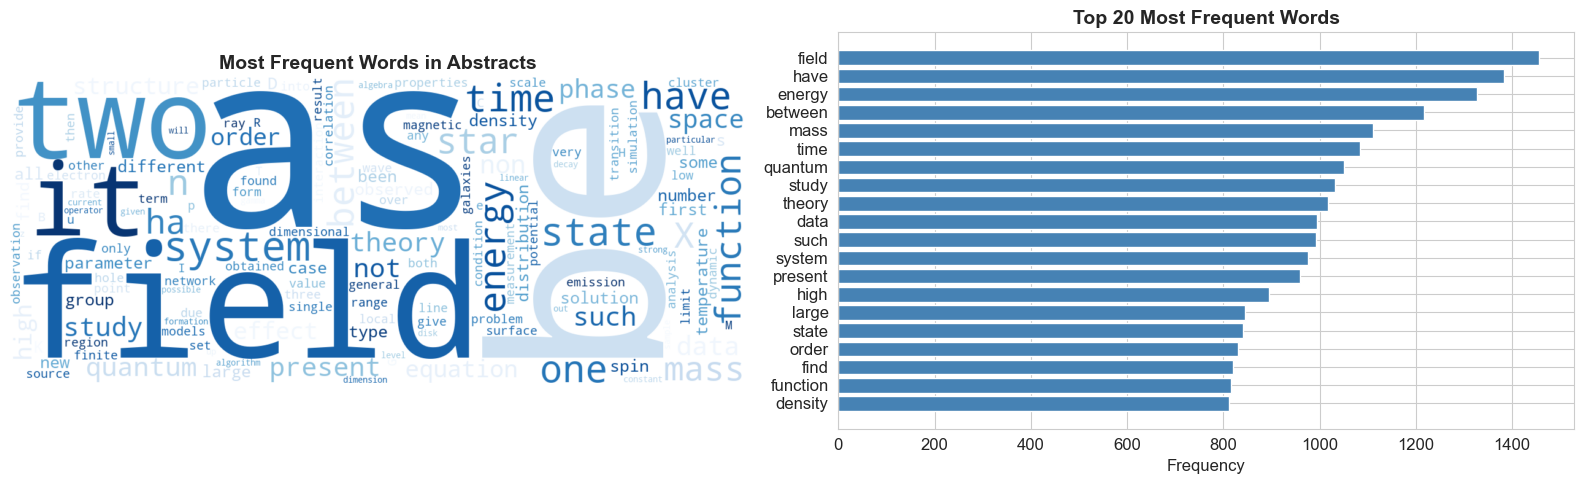

Plot saved → reports/wordcloud.png


In [14]:
from wordcloud import WordCloud

# Combine all abstracts into one text
all_text = ' '.join(df['abstract'].tolist())

# Remove common words that are not useful
custom_stopwords = {
    'the','a','an','and','or','but','in','on','at','to',
    'for','of','with','by','from','is','are','was','were',
    'this','that','these','those','we','our','their','its',
    'also','however','thus','hence','while','since','using',
    'used','use','show','shown','shows','based','paper',
    'propose','proposed','method','approach','model','results',
    'can','may','which','where','when','how','than','more'
}

# Generate word cloud
wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    max_words=150,
    stopwords=custom_stopwords,
    colormap='Blues',
    collocations=False
).generate(all_text)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Word cloud
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words in Abstracts',
                  fontsize=14, fontweight='bold')

# Top 20 most frequent words bar chart
from collections import Counter
import re

words = re.findall(r'\b[a-z]{4,}\b', all_text.lower())
words = [w for w in words if w not in custom_stopwords]
top_words = Counter(words).most_common(20)

words_list  = [w[0] for w in top_words]
counts_list = [w[1] for w in top_words]

axes[1].barh(words_list[::-1], counts_list[::-1], color='steelblue')
axes[1].set_title('Top 20 Most Frequent Words',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('reports/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/wordcloud.png")

**2.5 : Publication Trends Over Time**


   Year range : 2007 → 2025
   Papers with valid date : 5000


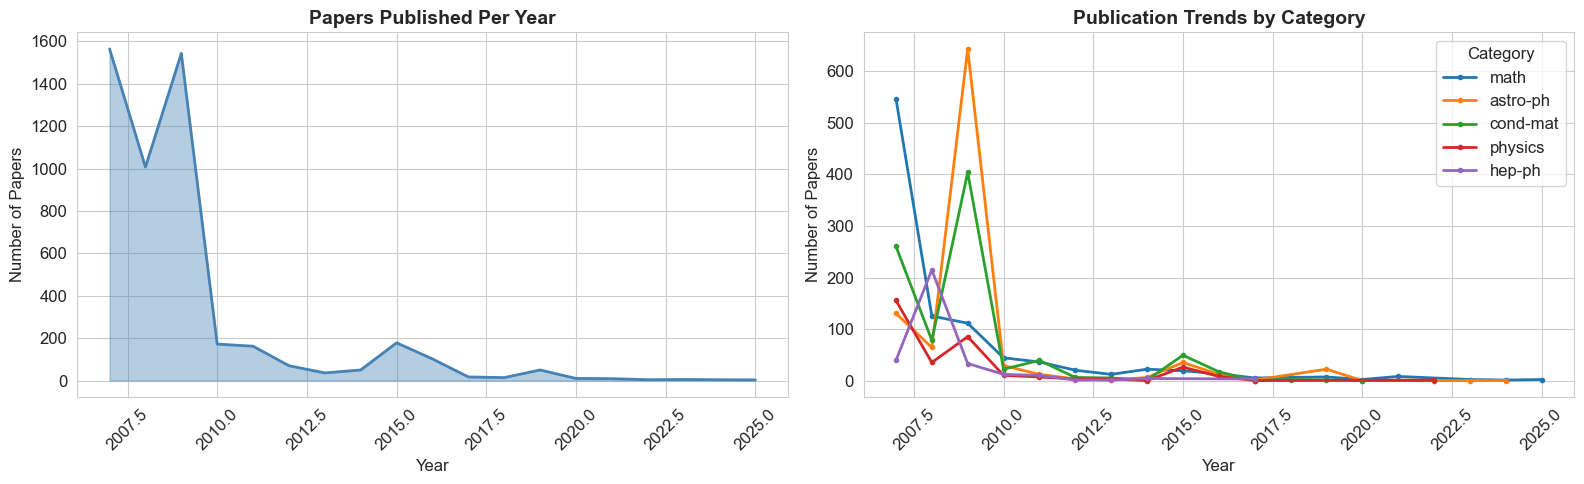

Plot saved → reports/publication_trends.png


In [15]:
# Extract year from date column
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year

# Remove invalid years
df_valid = df[df['year'].between(1990, 2025)]

print(f"   Year range : {df_valid['year'].min()} → {df_valid['year'].max()}")
print(f"   Papers with valid date : {len(df_valid)}")

# Count papers per year
papers_per_year = df_valid['year'].value_counts().sort_index()

# Count papers per year per category (top 5)
top5_cats = df['main_category'].value_counts().head(5).index
df_top5   = df_valid[df_valid['main_category'].isin(top5_cats)]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total papers per year
axes[0].fill_between(papers_per_year.index, papers_per_year.values,
                     alpha=0.4, color='steelblue')
axes[0].plot(papers_per_year.index, papers_per_year.values,
             color='steelblue', linewidth=2)
axes[0].set_title('Papers Published Per Year',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)

# Papers per year by category
for cat in top5_cats:
    cat_data = df_top5[df_top5['main_category'] == cat]
    yearly   = cat_data['year'].value_counts().sort_index()
    axes[1].plot(yearly.index, yearly.values, marker='o',
                 markersize=3, linewidth=2, label=cat)

axes[1].set_title('Publication Trends by Category',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Papers')
axes[1].legend(title='Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('reports/publication_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → reports/publication_trends.png")

**2.6 : Correlation Heatmap**


   Numerical features created :
   - nb_words        : word count of abstract
   - nb_chars        : character count of abstract
   - nb_authors      : number of authors
   - has_journal     : has journal reference (0/1)
   - has_doi         : has DOI (0/1)
   - has_comments    : has comments (0/1)
   - abstract_density: words/chars ratio
   - year            : publication year


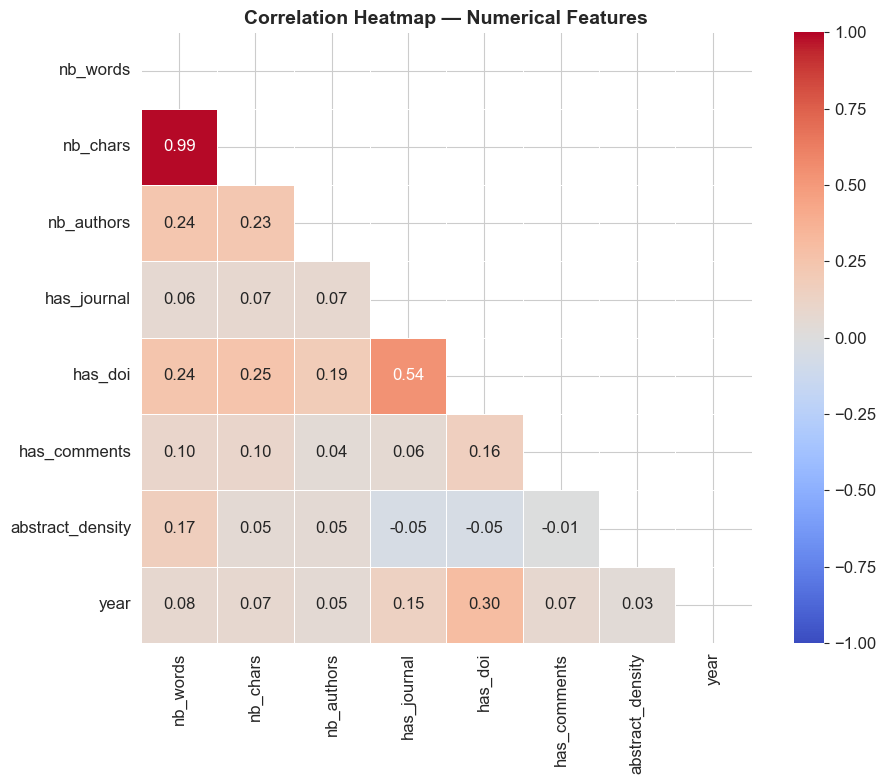

 Plot saved → reports/correlation_heatmap.png

  EDA COMPLETE — Key Insights
  • Dataset    : 5000 papers, 21 features
  • Categories : 18 unique domains
  • Top domain : math
  • Avg abstract length : 122 words
  • Year range : 2007 → 2025
  • 4 plots saved in reports/


In [16]:
# Create numerical features for correlation
df['nb_authors']     = df['authors'].apply(lambda x: len(x.split(',')) if x else 0)
df['has_journal']    = (df['journal_ref'] != '').astype(int)
df['has_doi']        = (df['doi'] != '').astype(int)
df['has_comments']   = (df['comments'] != '').astype(int)
df['abstract_density'] = df['nb_words'] / df['nb_chars'].replace(0, 1)

print(f"\n   Numerical features created :")
print(f"   - nb_words        : word count of abstract")
print(f"   - nb_chars        : character count of abstract")
print(f"   - nb_authors      : number of authors")
print(f"   - has_journal     : has journal reference (0/1)")
print(f"   - has_doi         : has DOI (0/1)")
print(f"   - has_comments    : has comments (0/1)")
print(f"   - abstract_density: words/chars ratio")
print(f"   - year            : publication year")

# Select numerical columns
num_cols = ['nb_words', 'nb_chars', 'nb_authors',
            'has_journal', 'has_doi', 'has_comments',
            'abstract_density', 'year']

corr_matrix = df[num_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved → reports/correlation_heatmap.png")

# EDA Summary
print("\n" + "=" * 60)
print("  EDA COMPLETE — Key Insights")
print("=" * 60)
print(f"  • Dataset    : {len(df)} papers, {df.shape[1]} features")
print(f"  • Categories : {df['main_category'].nunique()} unique domains")
print(f"  • Top domain : {df['main_category'].value_counts().index[0]}")
print(f"  • Avg abstract length : {df['nb_words'].mean():.0f} words")
print(f"  • Year range : {df['year'].min():.0f} → {df['year'].max():.0f}")
print(f"  • 4 plots saved in reports/")
print("=" * 60)